# Part 5: Data-driven model of battery with eDMDc

While the previous data-driven model of the battery created with augmented states in DMDc provided good predictive capabilities, there is room for further improvement. Here we explore the extended DMDc method and demonstrate how to incoporate the trained model in Jaxonomy.

## Dataset
We utilise the same dataset as in the previous tutorial. We also resample the dataset at a frequency of 10Hz.

## Extended Dynamic Mode Decomposition with control (eDMDc)

Unlike, the previous example where we had to invent relevant features to augment the state with, in eDMDc such features can be created by using known basis functions. For example, if our state is $\mathbf{x}\in \mathbb{R}^n$, a Gaussian basis function with center $\mathbf{c}\in \mathbb{R}^n$, can be of the form

$$
\phi(\mathbf{x, \mathbf{c}}) = \exp \left(  - \frac{||\mathbf{x}-\mathbf{c}||^2} {2 \sigma^2}   \right),
$$

where the parameter $\sigma$ is related to the width of the Gaussian kernel.

By specifying the type and number of basis fucntions to use, one can create a rich basis. For example, using two basis functions of the above type, we would seek to find a dynamics model of the following form:


\begin{align}
\begin{pmatrix}
v_t[k+1] \\ d[k+1] \\ \phi_1[k+1] \\ \phi_2[k+1]
\end{pmatrix} = 
A 
\begin{pmatrix}
v_t[k] \\ d[k]  \\ \phi_1[k] \\ \phi_2[k]
\end{pmatrix} +
B
\left( i[k] \right),
\end{align},

where $\phi_1$ and $\phi_2$ are Gaussian kernels. The parameters of the basis functions, $\sigma$ and $\mathbf{c}$, can be provided by the user or estimated by the training algorithm. In what follows, $\sigma$ will be user provided, and the centers $\mathbf{c}$ will be uniformly distributed within the training data.

> **Library note.** The eDMDc pieces originally hand-rolled in this notebook &mdash; RBF lifting, the operator fit, and the discrete-time lifted-linear predictor block &mdash; have been promoted into `jaxonomy.library.rom`. This notebook now uses `rbf_dictionary` (the Gaussian observable dictionary, identity observables first), `edmd` (extended DMD with control, returning the Koopman operator `K`, lifted input operator `B`, and de-lift matrix `C`), and the `KoopmanPredictor` block (the lifted-linear rollout $z[k{+}1]=Kz[k]+Bu[k]$, $x=Cz$). Each step below points at the library call that implements it.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from math import ceil

from jax import config

config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

from scipy.io import loadmat

train_file_name = "dataset_25deg/10-28-18_17.44 551_UDDS_25degC_LGHG2.mat"
val_file_name = "dataset_25deg/10-29-18_14.41 551_Mixed1_25degC_LGHG2.mat"

tain_data = loadmat(train_file_name)
val_data = loadmat(val_file_name)

Q = 3.0  # battery capacity is known to be 3Ah (LG HG2 cell)


def extract_features_from_matfile(filename, Q=3.0, dt=0.1):
    data = loadmat(filename)
    t = data["meas"][0][0][0]
    vt = data["meas"][0][0][2]
    curr = -data["meas"][0][0][3]
    D = -data["meas"][0][0][4]

    # Resample
    T_end = t[-1, 0]
    t_resampled = np.linspace(0.0, T_end, ceil(T_end / dt))
    vt_resampled = np.interp(t_resampled, t[:, 0], vt[:, 0])
    curr_resampled = np.interp(t_resampled, t[:, 0], curr[:, 0])
    D_resampled = np.interp(t_resampled, t[:, 0], D[:, 0])

    return (t_resampled, vt_resampled, curr_resampled, D_resampled)


t_train, vt_train, curr_train, d_train = extract_features_from_matfile(train_file_name)
t_val, vt_val, curr_val, d_val = extract_features_from_matfile(val_file_name)

We write a small helper to compute uniformly distributed centers for the Gaussian kernels. The lifting itself &mdash; mapping the state $\mathbf{x}$ to $[\,\mathbf{x},\ \phi_1(\mathbf{x}),\ \dots,\ \phi_{n_c}(\mathbf{x})\,]$ &mdash; is provided by the library dictionary `rbf_dictionary`.

In [2]:
from jaxonomy.library.rom import rbf_dictionary, edmd, KoopmanPredictor


def get_centers(x, n_centers):
    """
    Obtain uniformly distributed centers in the [min, max] range of
    each input feature.
    
    Args:
        x (ndarray): shape (n_input_features, n_samples)
        n_centers (int): number of uniformly distributed centres
        
    Returns:
        centers (ndarray): shape (n_centers, n_input_features)
        The uniformly distributed centers within the range of each input feature.
    """
    n_input_features, n_samples = x.shape
    
    # Initialize the centers array
    centers = np.zeros((n_centers, n_input_features))
    
    for i in range(n_input_features):
        # Get the minimum and maximum value of the current feature
        min_val = np.min(x[i, :])
        max_val = np.max(x[i, :])
        
        # Generate uniformly spaced values within this range
        centers[:, i] = np.linspace(min_val, max_val, n_centers)
    
    return centers

In [3]:
state_names = ["$v_t$", "$d$"]

state_data = np.vstack([vt_train, d_train])
control_data = curr_train.reshape((1, curr_train.size))

centers = get_centers(state_data, 10)

# `rbf_dictionary` builds the observable map g(x) = [x, exp(-eps ||x - c_j||^2)].
# Identity observables come first, so the physical state stays recoverable and we
# do NOT pre-augment the data ourselves. The notebook's sigma = 1/sqrt(2) matches
# the library's epsilon = 1/(2 sigma^2) = 1.0.
epsilon = 1.0
dictionary = rbf_dictionary(centers, epsilon=epsilon)

The fit is done by the library's `edmd`: it lifts each snapshot through the dictionary and least-squares fits the lifted-linear dynamics $\mathbf{z}[k{+}1] \approx K\,\mathbf{z}[k] + B\,\mathbf{u}[k]$, returning the Koopman operator $K$, the lifted input operator $B$, and the de-lift matrix $C$ (physical state $\approx C\,\mathbf{z}$). We wrap a small helper around the returned model to roll it forward one step at a time.

In [4]:
def simulate_edmdc(res, initial_state, U):
    """Roll the fitted Koopman model forward from an initial physical state.

    Each step re-lifts the physical state through the fitted dictionary,
    advances the lifted-linear dynamics z[k+1] = K z[k] + B u[k], then de-lifts
    x = C z[k+1]. This is exactly what the ``KoopmanPredictor`` block does inside
    ``jaxonomy.simulate`` (used further down); here we run it in plain numpy so we
    can report a prediction-error metric.

    Args:
        res: ``EDMDResult`` returned by ``edmd`` (holds K, B, C, dictionary).
        initial_state (ndarray): physical state x[0], shape (n_states,).
        U (ndarray): control inputs, shape (n_inputs, n_samples).

    Returns:
        X_sim (ndarray): physical state trajectory, shape (n_states, n_samples + 1).
    """
    g, K, B, C = res.dictionary, res.K, res.B, res.C
    n_states = initial_state.shape[0]
    n_samples = U.shape[1]

    X_sim = np.zeros((n_states, n_samples + 1))
    X_sim[:, 0] = initial_state

    for k in range(n_samples):
        z = np.asarray(g(jnp.asarray(X_sim[:, k])))
        z_next = K @ z + B @ U[:, k]
        X_sim[:, k + 1] = np.asarray(C @ z_next)
    return X_sim

In [5]:
X = state_data[:, :-1]  # physical state x[k]
X_prime = state_data[:, 1:]  # physical state x[k+1]
U = control_data[:, :-1]  # control input i[k]

# edmd lifts each snapshot through `dictionary` and least-squares fits the
# lifted-linear dynamics z[k+1] ~ K z[k] + B u[k]. K plays the role of the
# augmented A matrix, B the augmented input matrix, and C de-lifts back to (v_t, d).
res = edmd(X, X_prime, dictionary, U=U)

print("Koopman operator K (lifted dynamics matrix):")
print(res.K)

print("Lifted input operator B:")
print(res.B)

Koopman operator K (lifted dynamics matrix):
[[ 9.98626613e-01  2.84853848e-03  3.10383606e+01 -1.25623800e+02
   2.73918807e+02 -4.21866293e+02  5.05738379e+02 -4.89566867e+02
   3.82880274e+02 -2.33438009e+02  1.00760366e+02 -2.34851013e+01]
 [ 1.16035381e-06  9.99997923e-01 -2.51368083e-02  1.01700400e-01
  -2.21543320e-01  3.40672390e-01 -4.07517335e-01  3.93377014e-01
  -3.06574322e-01  1.86118979e-01 -7.99260574e-02  1.85156276e-02]
 [ 3.80396758e-04 -6.65628079e-04 -6.69235792e+00  3.10352715e+01
  -6.74233524e+01  1.03398499e+02 -1.23357680e+02  1.18771099e+02
  -9.23397206e+01  5.59370099e+01 -2.39772506e+01  5.54678926e+00]
 [ 5.25596987e-04 -9.42004526e-04 -1.04217407e+01  4.31244063e+01
  -9.16980895e+01  1.40927543e+02 -1.68513652e+02  1.62637347e+02
  -1.26762261e+02  7.69912771e+01 -3.30924312e+01  7.67724311e+00]
 [ 5.86375099e-04 -1.09092374e-03 -1.16352467e+01  4.71290785e+01
  -1.01827877e+02  1.58420132e+02 -1.89922452e+02  1.83800433e+02
  -1.43666174e+02  8.751703

>
> Note: With a package such as `pykoopman`, the training of the model could be achieved with:
>
>```python
>import pykoopman as pk
>
>state_data = np.vstack([vt_train, d_train]).T
>control_data = curr_train.reshape((curr_train.size, 1))
>
>edmdc = pk.regression.EDMDc()
>kernel_width = 1.0
>RBF = pk.observables.RadialBasisFunction(
>    rbf_type="gauss",
>    n_centers=10,
>    centers=None,
>    kernel_width=kernel_width, # kernel_width = 1/(2 sigma^2)
>    include_state=True,
>)
>
>model = pk.Koopman(observables=RBF, regressor=edmdc)
>model.fit(state_data, u=control_data)
>```

>and the trained model could be simulated with `model.simulate`.


We can now simulate the model, initialising the model at the initial values of the state measurements, and see how its predictions compare with the experiment data.

RMS: error: [np.float64(0.03173295414102889), np.float64(0.0019476830297772679)]


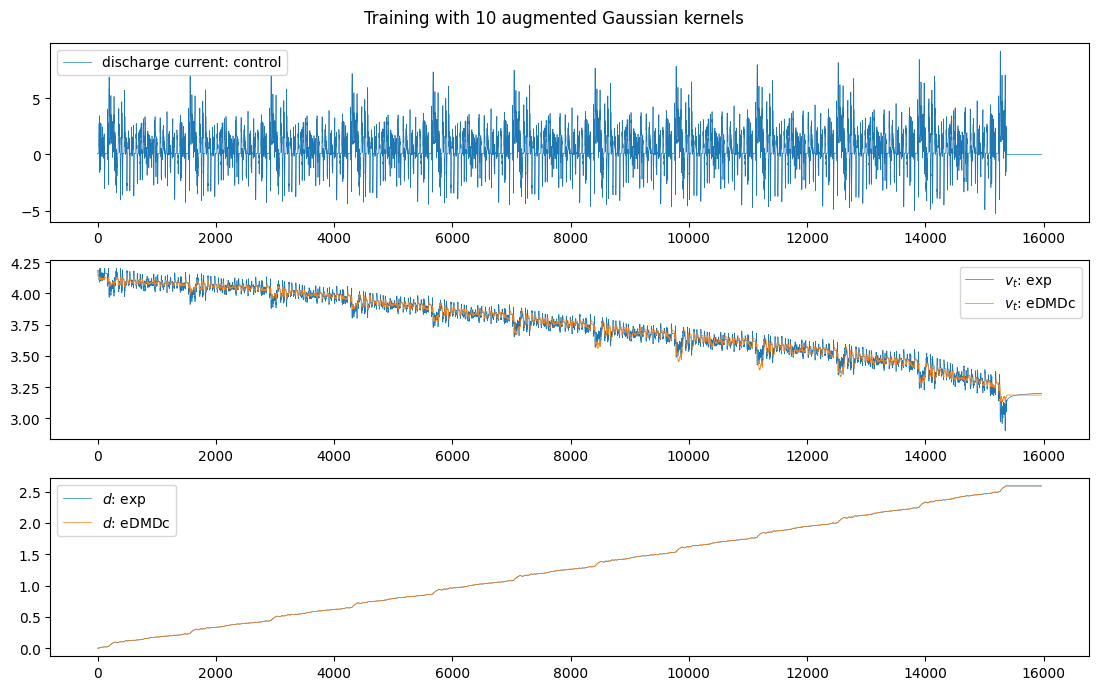

In [6]:
initial_state = state_data[:, 0]

pred_state = simulate_edmdc(res, initial_state, control_data[:, :-1])

def compute_prediction_error(pred_state, state_data):
    rms_err = []
    for y, x in zip(pred_state, state_data):
        rms_err.append(np.sqrt(np.average((y - x) ** 2)))
    return rms_err

print("RMS: error:", compute_prediction_error(pred_state, state_data))

lw = 0.5
fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(t_train, control_data[0, :], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_train, state_data[i, :], label=state_names[i] + ": exp", lw=lw)
    ax.plot(t_train, pred_state[i, :], label=state_names[i] + ": eDMDc", lw=lw)
    ax.legend(loc="best")
fig.suptitle("Training with 10 augmented Gaussian kernels")
plt.tight_layout()
plt.show()

### Validation

We can test the models performance on unseen data for validation

RMS: error: [np.float64(0.051745476949380115), np.float64(0.00337946970656781)]


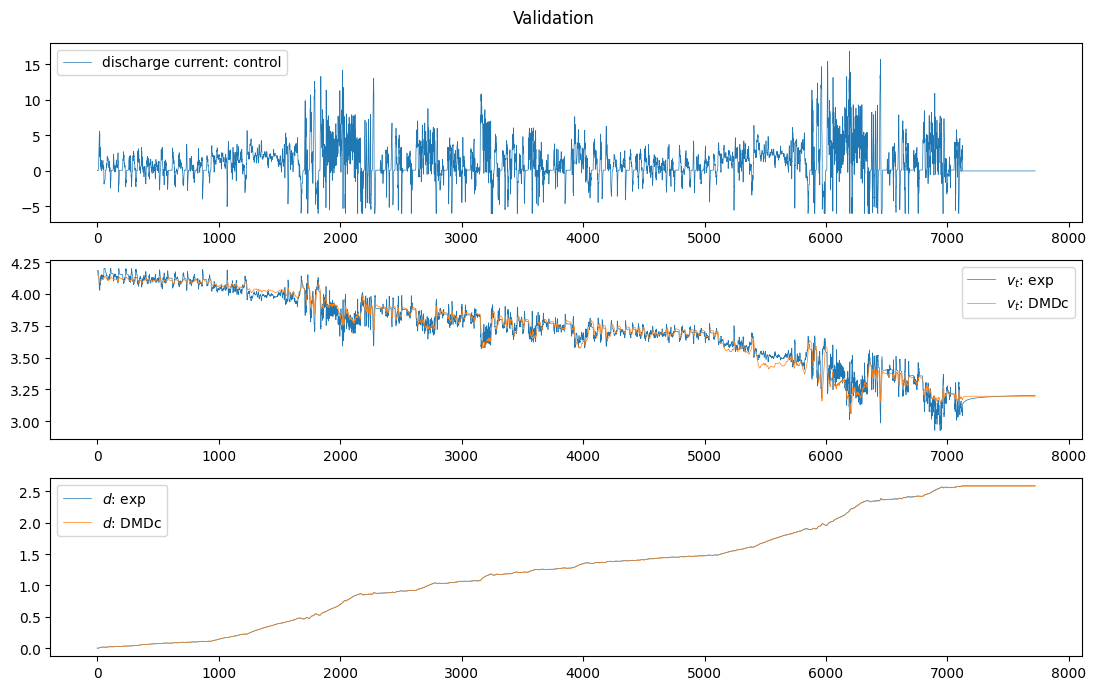

In [7]:
state_data = np.vstack([vt_val, d_val])
control_data = curr_val.reshape((1, curr_val.size))

initial_state = state_data[:, 0]

pred_state = simulate_edmdc(res, initial_state, control_data[:, :-1])

print("RMS: error:", compute_prediction_error(pred_state, state_data))

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(t_val, control_data[0,:], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_val, state_data[i,:], label=state_names[i] + ": exp", lw=lw)
    ax.plot(t_val, pred_state[i,:], label=state_names[i] + ": DMDc", lw=lw)
    ax.legend(loc="best")
fig.suptitle("Validation")
plt.tight_layout()
plt.show()

## Including the eDMDc model in Jaxonomy

The fitted Koopman model plugs straight into Jaxonomy through the library's `KoopmanPredictor` block. It stores the physical state, and on each discrete tick it lifts through the fitted dictionary, advances the lifted-linear dynamics $\mathbf{z}[k{+}1] = K\,\mathbf{z}[k] + B\,\mathbf{u}[k]$, and de-lifts $\mathbf{x} = C\,\mathbf{z}$ &mdash; the same rollout as `simulate_edmdc` above, but jax-traceable and simulatable inside `jaxonomy.simulate`. We drive its input port with a small discrete source block replaying the recorded current.

In [8]:
import jaxonomy
from jaxonomy.framework import LeafSystem

from jaxonomy.simulation import SimulatorOptions, ODESolverOptions

from typing import NamedTuple


# The Extended DMDc dynamics are now provided by the library's `KoopmanPredictor`
# block (imported above from jaxonomy.library.rom). We only need a small source
# block to replay the recorded discharge current into its input port.
class DiscreteSource(LeafSystem):
    class DiscreteStateType(NamedTuple):
        index: jnp.int64
        source_val: jnp.float64

    def __init__(self, val_array, dt, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.val_array = val_array
        self.dt = dt

        self.declare_discrete_state(
            default_value=self.DiscreteStateType(index=0, source_val=val_array[0]),
            as_array=False,
        )

        self.declare_periodic_update(
            self._update,
            period=self.dt,
            offset=0,
        )

        self.declare_output_port(
            self._compute_output,
            default_value=self.val_array[0],
            period=self.dt,
            offset=0.0,
            requires_inputs = False,
        )

    def _compute_output(self, time, state, **params):
        return state.discrete_state.source_val

    def _update(self, time, state, *inputs, **params):
        index = state.discrete_state.index
        index = index + 1
        source_val = self.val_array[index]
        return self.DiscreteStateType(index=index, source_val=source_val)

We can now include the learnt data-driven system in Jaxonomy and simulate.

In [9]:
builder = jaxonomy.DiagramBuilder()
initial_state = jnp.array([vt_train[0], d_train[0]])
dt = 0.1

edls = builder.add(
    KoopmanPredictor(
        K=res.K,
        C=res.C,
        dictionary=res.dictionary,
        B=res.B,
        dt=dt,
        initial_state=initial_state,
        name="edls",
    )
)

control = builder.add(DiscreteSource(jnp.array(curr_train), dt=dt, name="control"))

builder.connect(control.output_ports[0], edls.input_ports[0])

diagram = builder.build()
context = diagram.create_context()

recorded_signals = {
    "state": diagram["edls"].output_ports[0],
    "control": diagram["control"].output_ports[0],
}

options = SimulatorOptions(max_major_steps=ceil(t_train[-1] / dt))
sol = jaxonomy.simulate(
    diagram,
    context,
    (0.0, t_train[-1]),
    options=options,
    recorded_signals=recorded_signals,
)

22:40:25.137 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=159656, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


/Users/reda/Dev/jaxy/jaxonomy/.claude/worktrees/surrogate-modeling-rom-support-353830/jaxonomy/simulation/errors.py:157: UserWarning: jaxonomy.simulate: the recording buffer (buffer_length=159656) filled; the trajectory was recorded at reduced resolution (79829 of 159657 samples, keeping every 2th). The recorded time-series still starts at t0 and covers the whole trajectory (the head is no longer dropped; the last kept sample may precede tf by up to 2 steps). Set SimulatorOptions(buffer_length=159658) or larger to capture every sample, loosen rtol/atol, or reduce the number of recorded signals.
  return func(*args, **kwargs)


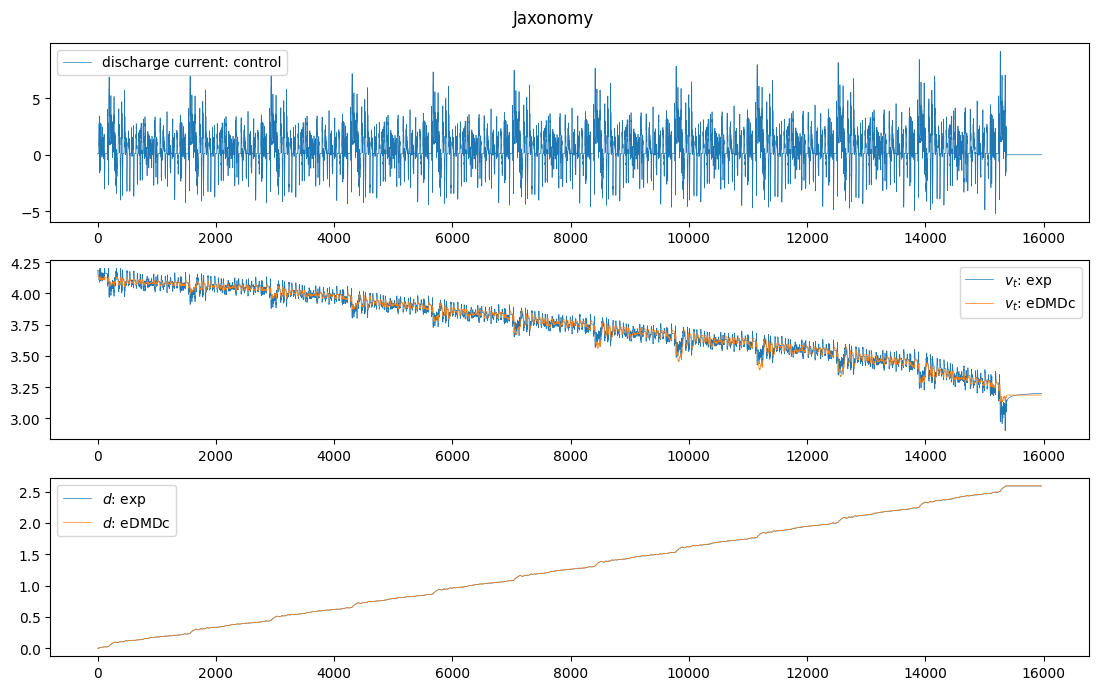

In [10]:
state_data = np.vstack([vt_train, d_train]).T  # exp data for plotting

fig, axs = plt.subplots(len(state_names) + 1, 1, figsize=(11, 7))
axs[0].plot(sol.time, sol.outputs["control"], label="discharge current: control", lw=lw)
axs[0].legend()
for i, ax in enumerate(axs[1:]):
    ax.plot(t_train, state_data[:, i], label=state_names[i] + ": exp", lw=lw)
    ax.plot(
        sol.time, sol.outputs["state"][:, i], label=state_names[i] + ": eDMDc", lw=lw
    )
    ax.legend(loc="best")
fig.suptitle("Jaxonomy")
plt.tight_layout()
plt.show()